# Project: Verhuuraantallen
### Team: Undefined
### Teamleden:
- **Sebastiaan Westerlaken**
- **Michal Kakol**

# 0. Setup:

### 0.1. Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 0.2. Data Mining:

In [2]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")
df_submission = pd.read_csv("../data/sample_submission.csv")

### 0.3. Data Cleaning:

Data is al schoongemaakt. Er zijn geen null values en data integrity klopt ook door vastgestlde normalisatie van 'temp', 'atemp', 'hum', 'windspeed' en encoding van 'holiday' and 'weathersit'.

In [3]:
print(df_train.info())
print(df_train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16637 entries, 0 to 16636
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date_hour   16637 non-null  object 
 1   holiday     16637 non-null  int64  
 2   weathersit  16637 non-null  int64  
 3   temp        16637 non-null  float64
 4   atemp       16637 non-null  float64
 5   hum         16637 non-null  float64
 6   windspeed   16637 non-null  float64
 7   cnt         16637 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 1.0+ MB
None
            holiday    weathersit          temp         atemp           hum  \
count  16637.000000  16637.000000  16637.000000  16637.000000  16637.000000   
mean       0.028671      1.415580      0.504745      0.482608      0.624756   
std        0.166885      0.637298      0.192369      0.171557      0.193227   
min        0.000000      1.000000      0.020000      0.000000      0.000000   
25%        0.000000 

# 1. EDA:

### Meetniveaus:
- Nominaal: "holiday"
- Ordinaal: "weathersit"
- Continuous/ratio: "temp", "atemp", "hum", "windspeed", "cnt" (target)
- Tijdseries: "date_hour"

Continuous variabelen zijn grotendeels normaal verdeeld, maar "windspeed" is licht rechts-scheef.

### Correlaties en belangrijkste variabelen:
Sterk gecorreleerde variabelen met het target cnt: "temp" 0.43, "hum" -0.36.
Zwakke correlaties: "windspeed" 0.10, "weathersit" -0.12, "holiday" -0.03.
"temp" en "atemp" zijn bijna volledig gecorreleerd, waardoor er sprake is van Multicollinearity en dus "atemp" zou uitgesloten worden bij modeling.

### Tijdseries observaties:
Sampling is hoofdzakelijk per uur als meest voorkomende frequentie is 1 uur, maar er zijn nog 7 andere die zou moeten uniform sampling grbuiken mo ze te kunnen gebruiken bij modelleren.
Data bevat bijna 700 dagen (frequency) met 16.637 samples (number of samples).
- Trend: algemene stijging, met pieken in zomer en vroege herfst (rond 300) en dalen in winter (tussen 50–100). Dus de trend is eigenlijk hierbij een beetje iets tussen echte trend en grote schaal (jaarlijks) seasonality (die kan niet als seasonality gelabeled worden omdat er bestaan niet eens 2 cycles)
- Seizoenspatroon: maandelijkse cycle period is hierbij heel zacht met zachte (maar iets sterkste) wekelijkse cycles er ook. Jaarlijkse patronen zijn observeerbaar, maar omdat er is "slechts" onder 2 jaar data beschikbaar ze kunnen niet gebuikt worden. Ik heb eerder time series data opgezet naar daily om die sneller te kunnen berekenen, omdat het deed te lang door de hoeveelheid van samples (meestal hourly voor bijna 2 jaar). Dit gaaf aan heel slechte seasonality, omdat die vooral per uur aanwezig is, ik heb dit onderzocht door autocorrelatie. Het is ook logisch, omdat het einddoel is om een voorspelling te maken per uur. Uit Het hourly decomposition (in Feature Engineering) blijkt dat de data moest heel erg ge-smooth worden, door hourly seasonality.
- Noise: neemt toe met de tijd, starts rond -50 tot 50, eindigt rond -150 tot 75, wat relatief groter is dan het seizoenspatroon.

# Basis statistiek:
Continuous:
               temp         atemp           hum     windspeed           cnt
count  16637.000000  16637.000000  16637.000000  16637.000000  16637.000000
mean       0.504745      0.482608      0.624756      0.190310    190.477009
std        0.192369      0.171557      0.193227      0.121915    182.026755
min        0.020000      0.000000      0.000000      0.000000      1.000000
25%        0.340000      0.333300      0.470000      0.104500     41.000000
50%        0.520000      0.500000      0.620000      0.194000    143.000000
75%        0.660000      0.621200      0.780000      0.253700    282.000000
max        1.000000      1.000000      1.000000      0.850700    977.000000
Ordinal:
weathersit
1    11078
2     4207
3     1349
4        3
Name: count, dtype: int64
Nominal:
holiday
0    16160
1      477
Name: count, dtype: int64


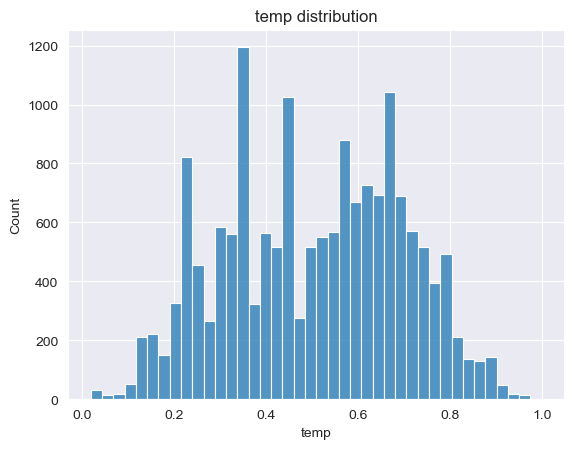

temp: skew=-0.07, kurtosis=-0.91


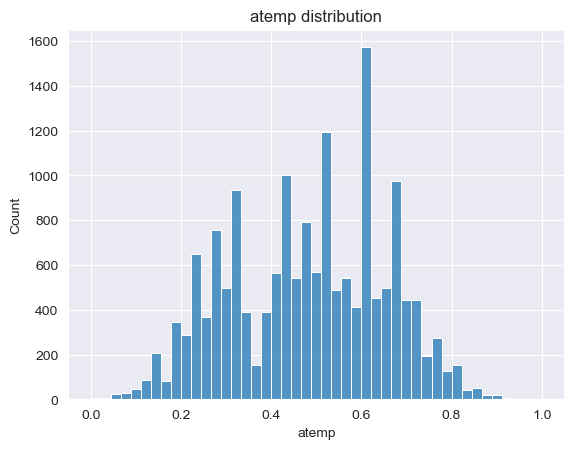

atemp: skew=-0.16, kurtosis=-0.80


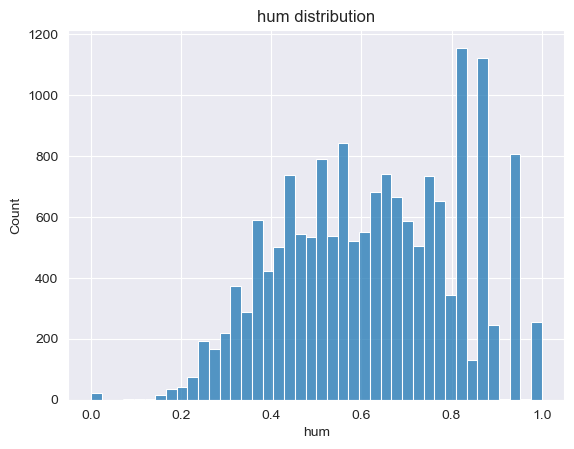

hum: skew=-0.11, kurtosis=-0.83


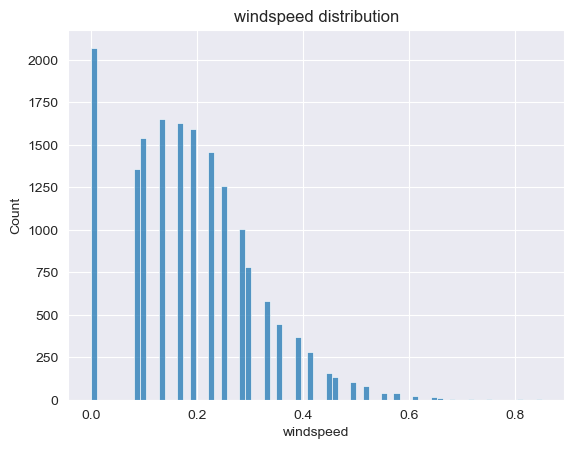

windspeed: skew=0.57, kurtosis=0.60
Spearman (temp vs cnt): rho=0.43, p=0.0000
Spearman (atemp vs cnt): rho=0.43, p=0.0000
Spearman (hum vs cnt): rho=-0.36, p=0.0000
Spearman (windspeed vs cnt): rho=0.13, p=0.0000
Spearman (weathersit vs cnt): rho=-0.12, p=0.0000
Point-Biserial (holiday vs cnt): r=-0.03, p=0.0006


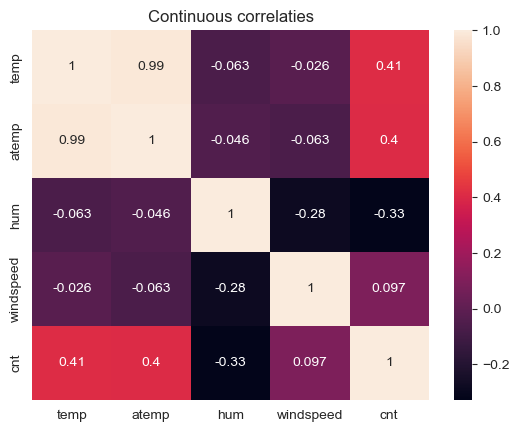

Time series:


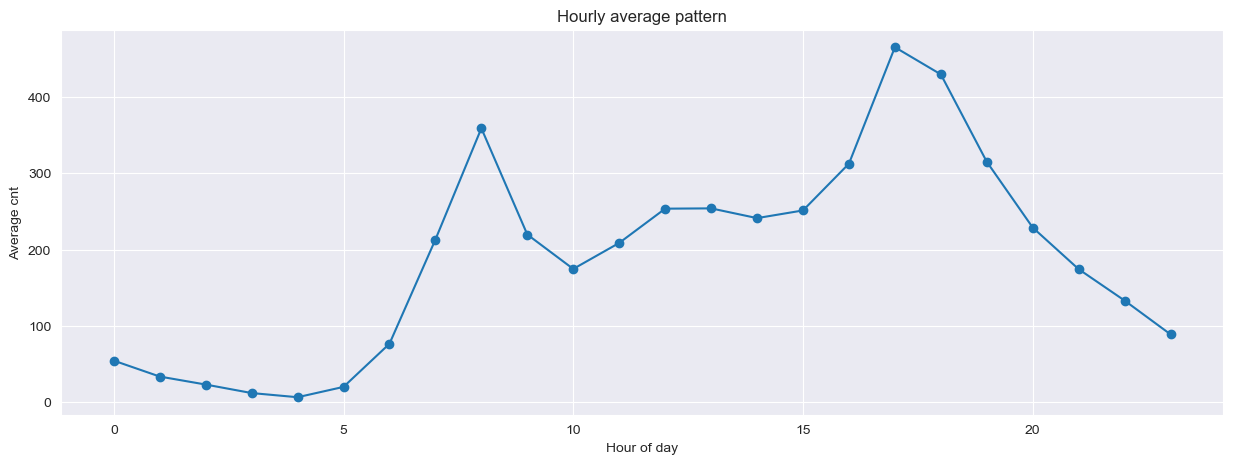

<Figure size 1500x500 with 0 Axes>

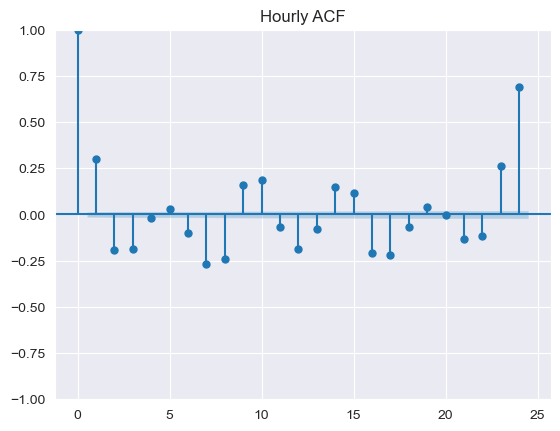

Sampling frequency: <TimedeltaArray>
[              NaT, '0 days 01:00:00', '0 days 02:00:00', '0 days 03:00:00',
 '0 days 13:00:00', '0 days 23:00:00', '0 days 07:00:00', '0 days 14:00:00',
 '1 days 13:00:00']
Length: 9, dtype: timedelta64[ns]
Main Sampling frequency: 0 days 01:00:00
Total samples: 16637
Total time: 699 days 23:00:00


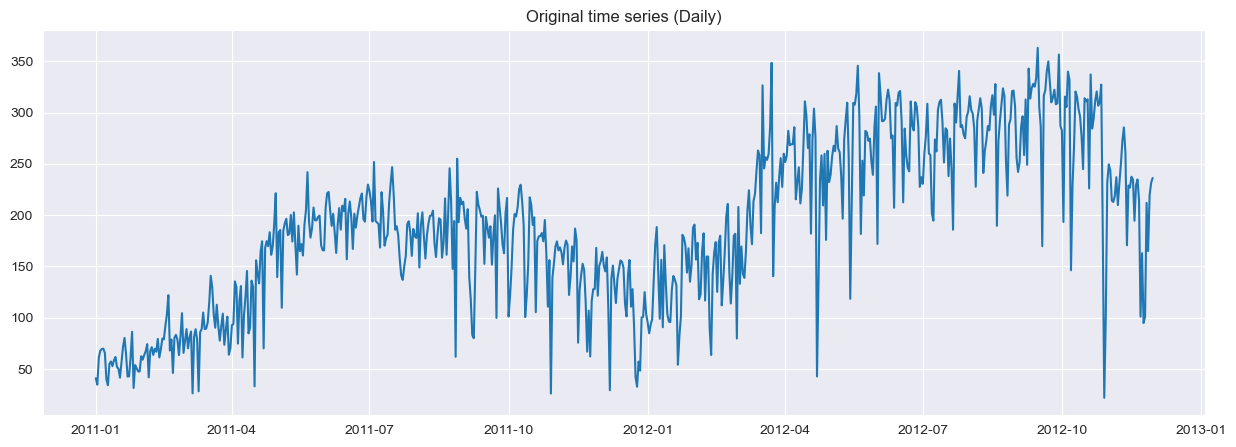

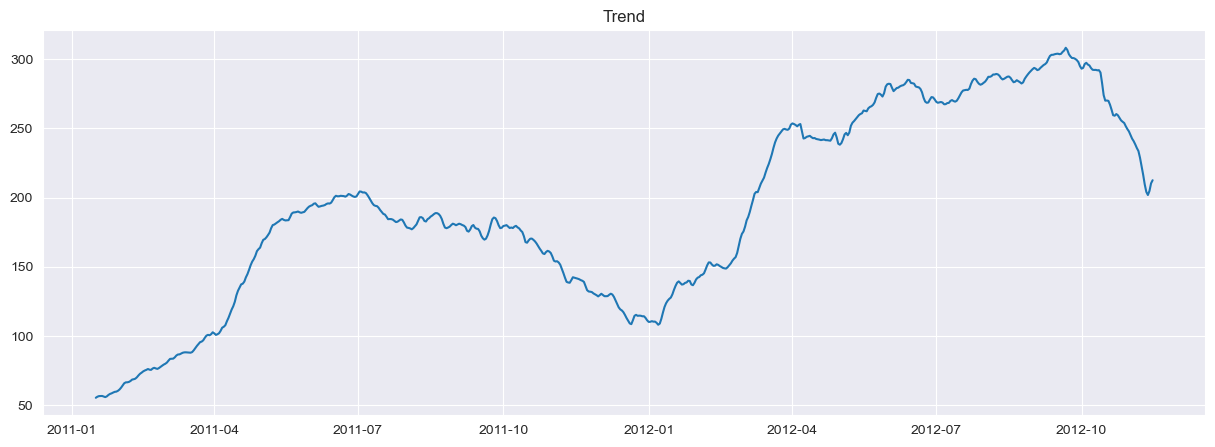

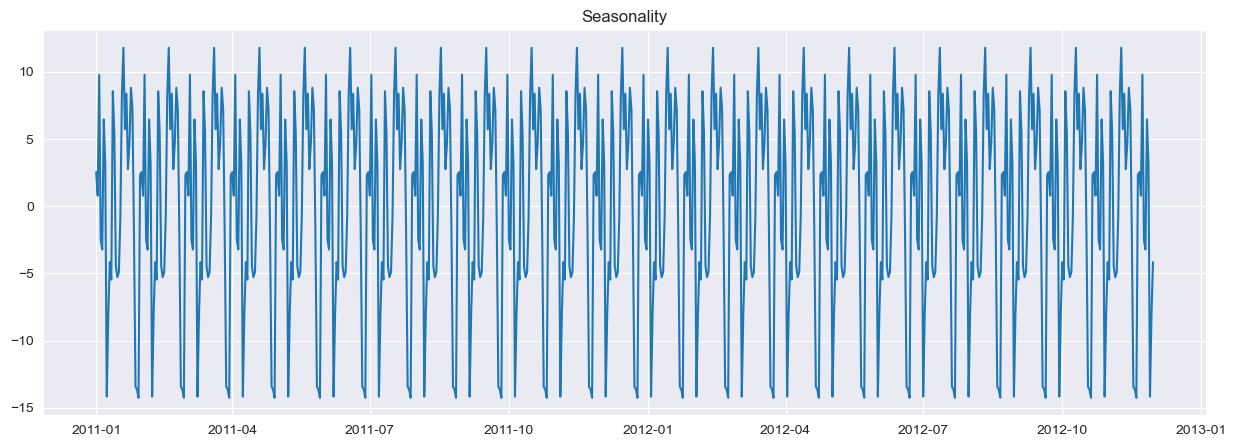

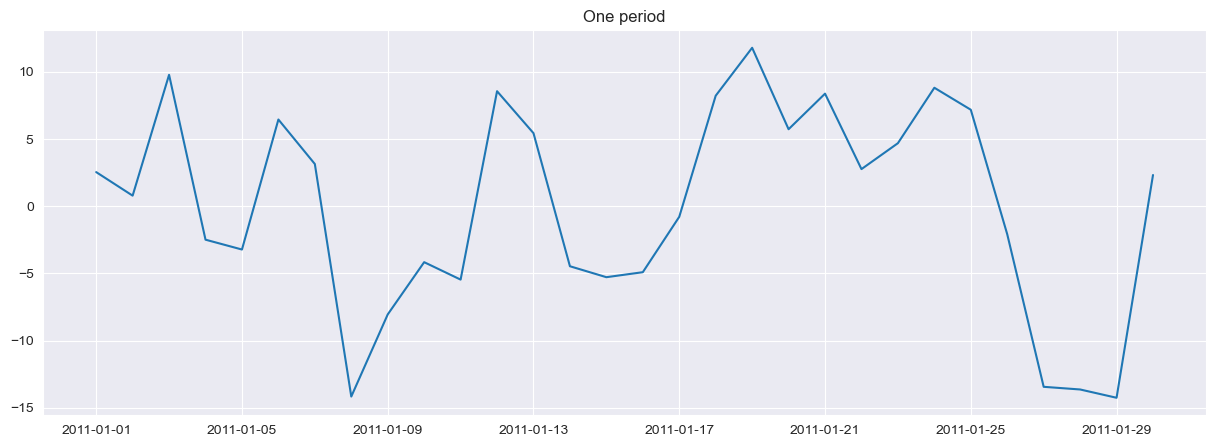

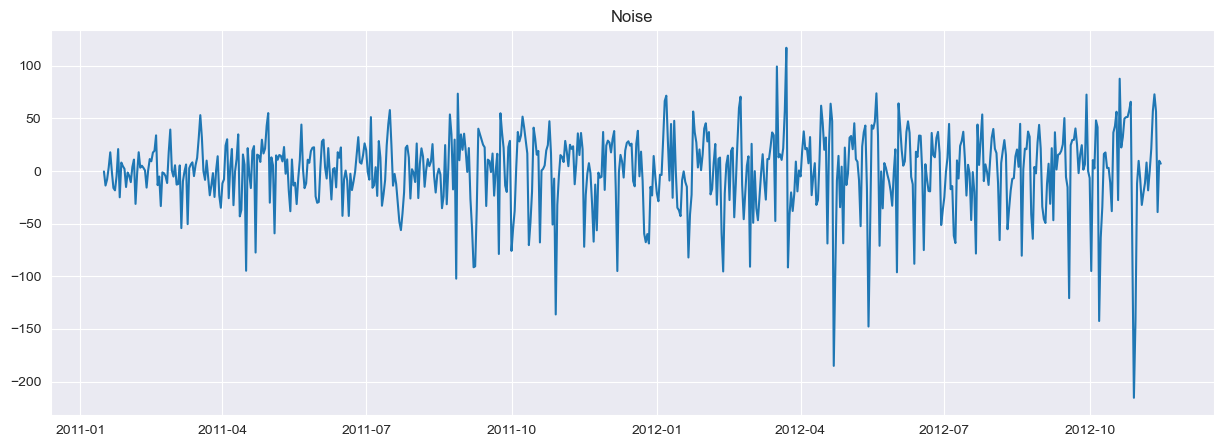

<Figure size 1500x500 with 0 Axes>

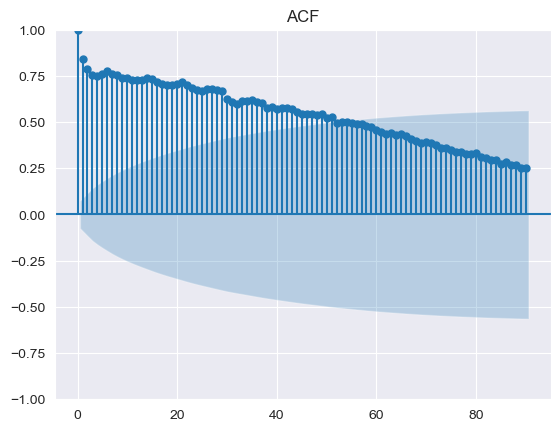

<Figure size 1500x500 with 0 Axes>

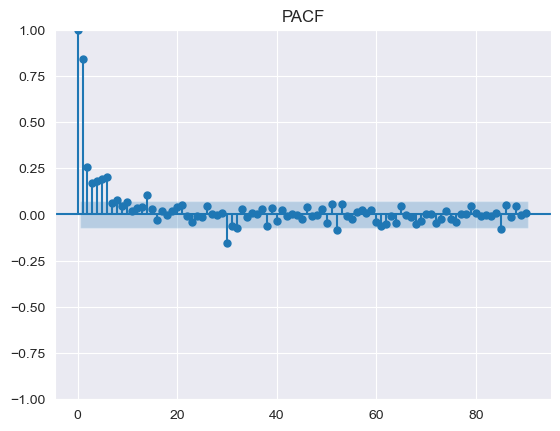

In [4]:
from functions.eda import eda
eda(
    df_train,
    target_col='cnt',
    nominal_cols=['holiday'],
    ordinal_cols=['weathersit'],
    timeseries_col='date_hour'
)

# 2. Time Series Feature Engineering:

### 2.1. Sampling:

In deze stap heb ik de kolom “date_hour” omgezet naar een echt datetime-type en daarna als index gebruikt. Vervolgens heb ik de data opnieuw gesampled naar een vaste frequentie zodat alle tijdstappen even groot zijn. Dit is nodig om time series features te kunnen maken. De data zelf is erg noisy door het hoge frequentie over lange termijn. Daardoor lijkt de messy lijnplot bijna op een crumbled histogram. Om de trend zichtbaar te krijgen moet er daarom vrij zwaar gesmooth worden. Uit de eerdere EDA kwam al naar voren dat de hourly seasonality het sterkst zijn. Wekelijkse en maandelijkse patronen zijn wel haalbaar om uit de data te halen, want die waren al gedeeltelijk zichtbaar in de autocorrelatie en sluiten aan bij de eerste observaties uit de EDA.

<Axes: xlabel='date_hour'>

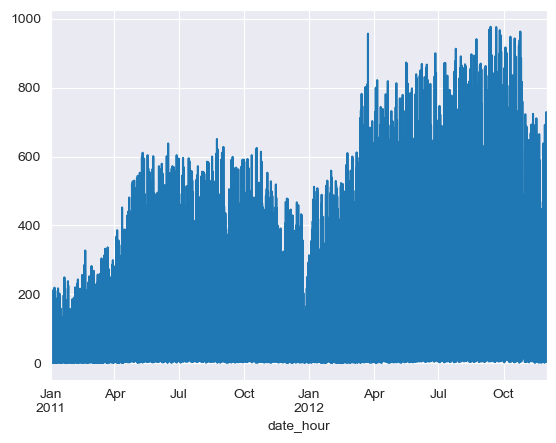

In [5]:
from functions.feature_engineering_timeseries import time_series_setup
df_setup = time_series_setup(df_train, datetime_col='date_hour', uniform_sampling='h') # Every hour
df_setup['cnt'].plot()

### 2.2. Decomposition:

In deze stap gebruik ik een rolling moving average om de data smoother te maken en een duidelijke trend te krijgen. Ik gebruik expres niet seasonal_decompose uit statsmodels, omdat die methode de trend en de daily seasonality tegelijk gladstrijkt. Bij deze dataset zorgt dat ervoor dat de dagelijkse seizoenspatronen worden kwijd geraakt. Door eerst zelf de trend eruit te halen en daarna het gemiddelde per uur van de dag te nemen, worden trend en seasonality apart behandeld. Zo blijft de trend smooth en de seasonal range blijft realistisch. De noise blijft wel zichtbaar, maar het is nu beter te scheiden van de andere componenten. De smoothing window voor de trend staat heel hoog (1000), maar dat is nodig door hoe messy en high frequency de data is. Dit werkt, omdat de seasonal component apart wordt berekend en dus niet beïnvloed wordt door deze sterke smoothing. De seasonality plot zelf is moeilijk leesbaar door de hoge frequentie, maar ik laat hem staan omdat hij wel nuttig is als je lagere frequenties (zoals monthly patterns) wilt testen. Onder de plot laat ik een extracted period zien om een beter beeld te krijgen van een cycle period.

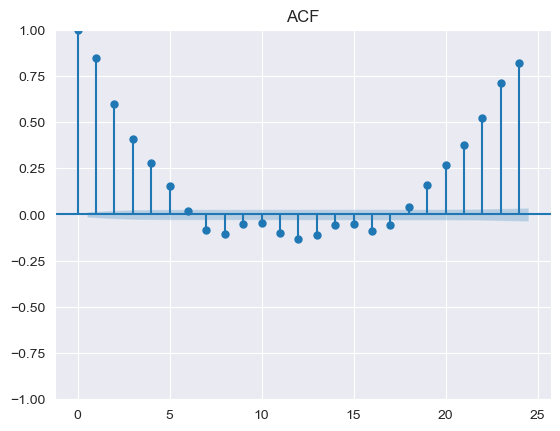

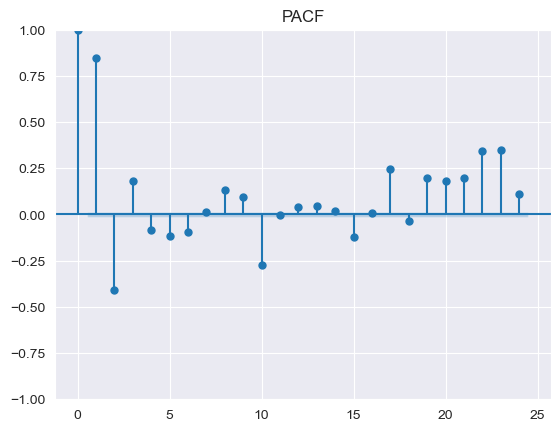

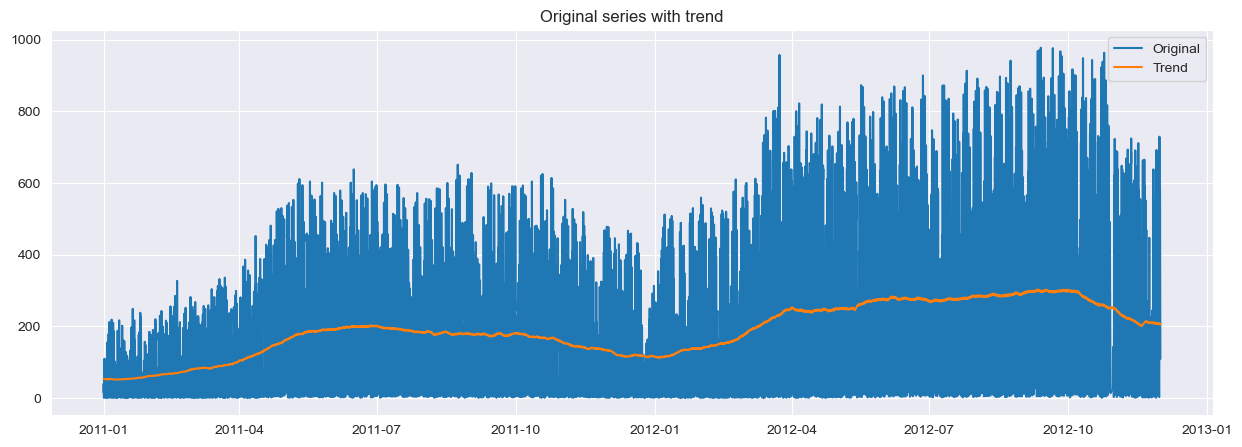

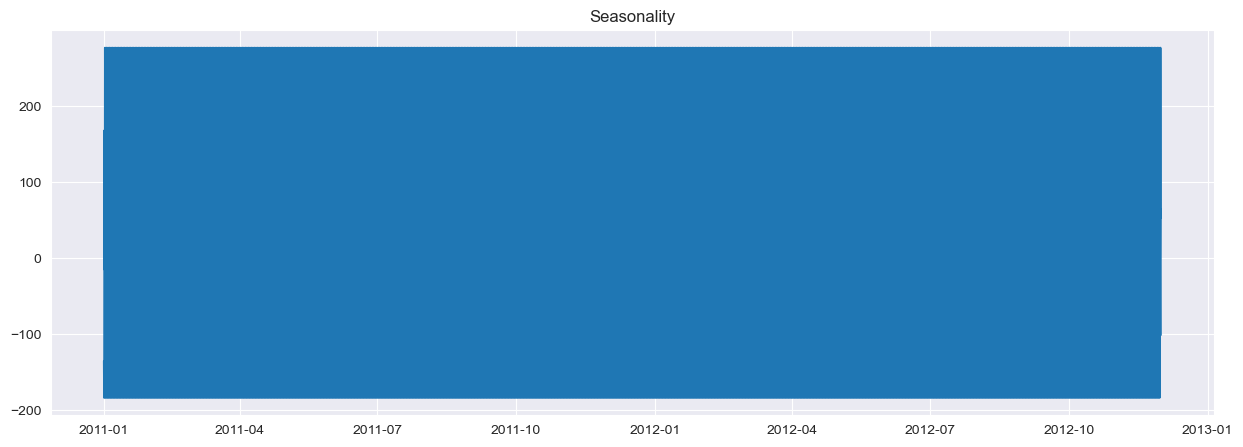

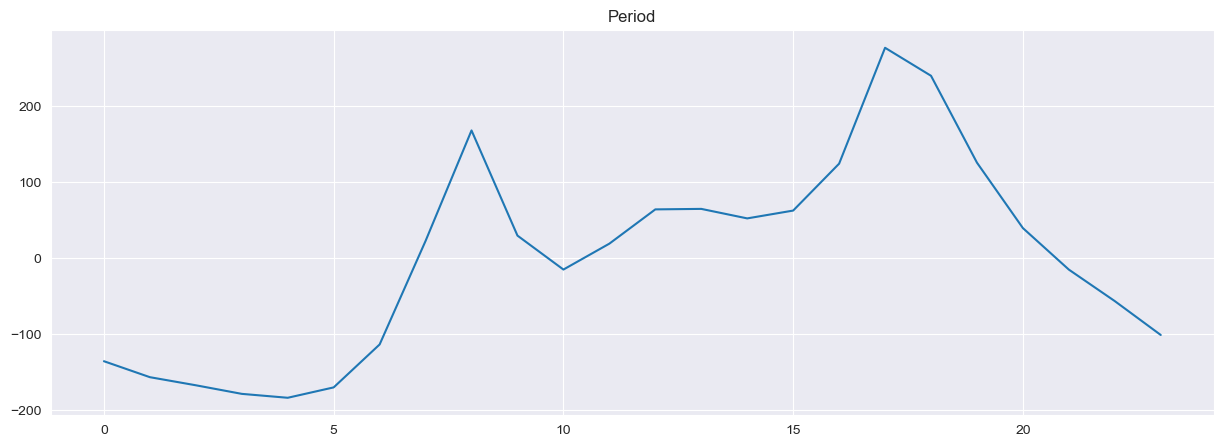

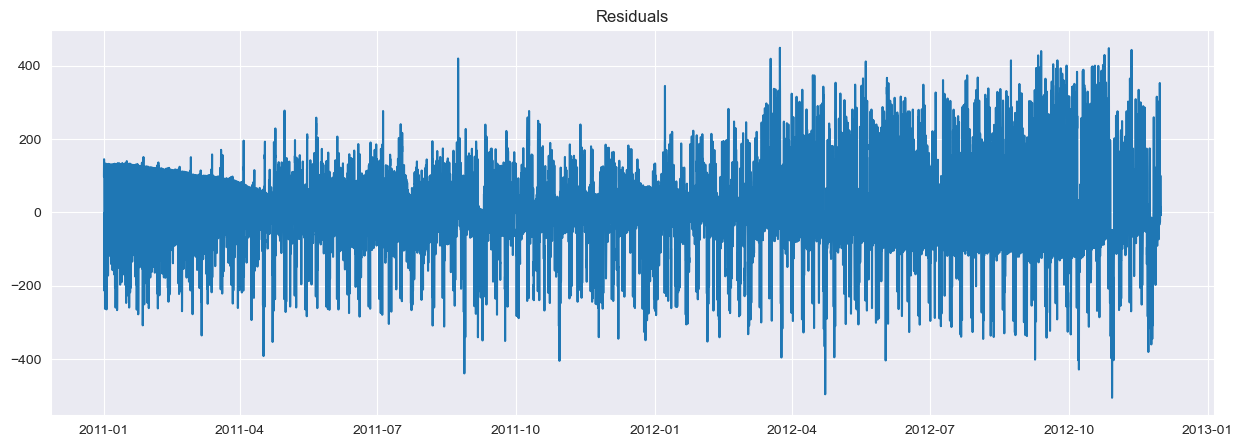

,holiday,weathersit,temp,atemp,hum,windspeed,cnt,trend,seasonal,resid
date_hour,,,,,,,,,,
2011-01-01 00:00:00,0.0,1.0,0.24,0.2879,0.81,0.0000,16.0,53.880000,-135.381726,97.501726
2011-01-01 01:00:00,0.0,1.0,0.22,0.2727,0.80,0.0000,40.0,53.878244,-156.378526,142.500282
2011-01-01 02:00:00,0.0,1.0,0.22,0.2727,0.80,0.0000,32.0,53.852590,-167.021135,145.168545
2011-01-01 03:00:00,0.0,1.0,0.24,0.2879,0.75,0.0000,13.0,53.813121,-178.313156,137.500035
2011-01-01 04:00:00,0.0,1.0,0.24,0.2879,0.75,0.0000,1.0,53.759921,-183.460625,130.700704
...,...,...,...,...,...,...,...,...,...,...
2012-11-30 19:00:00,0.0,1.0,0.32,0.3485,0.66,0.0000,377.0,204.887129,125.718526,46.394345
2012-11-30 20:00:00,0.0,1.0,0.32,0.3485,0.66,0.0000,245.0,204.972222,39.655528,0.372250
2012-11-30 21:00:00,0.0,1.0,0.30,0.3182,0.75,0.0896,183.0,205.137177,-14.920873,-7.216304


In [6]:
from functions.feature_engineering_timeseries import decomposition_featuring
features = decomposition_featuring(
    df_setup,
    target_col='cnt',
    period=24, # 24h cycle window
    lags=24, # 24h autocorrelation window
    trend_smooth=1000 # 1000 samples smoothing window
)
# Merging features to df
df_decomp = df_setup.merge(features, left_index=True, right_index=True)
display(df_decomp)

### 2.3. Linearity:

Er is geen linear of exponentieel verband gevonden in de drie hoofdperioden dat het waard zou zijn om aparte features voor te maken. Ik had gehoopt dat ten minste de weekly lag dit patroon zou laten zien (groei richting het weekend met piek in het weekend), maar door de extreem hoge range over het hele jaar lijkt het in de visualisaties vlak.

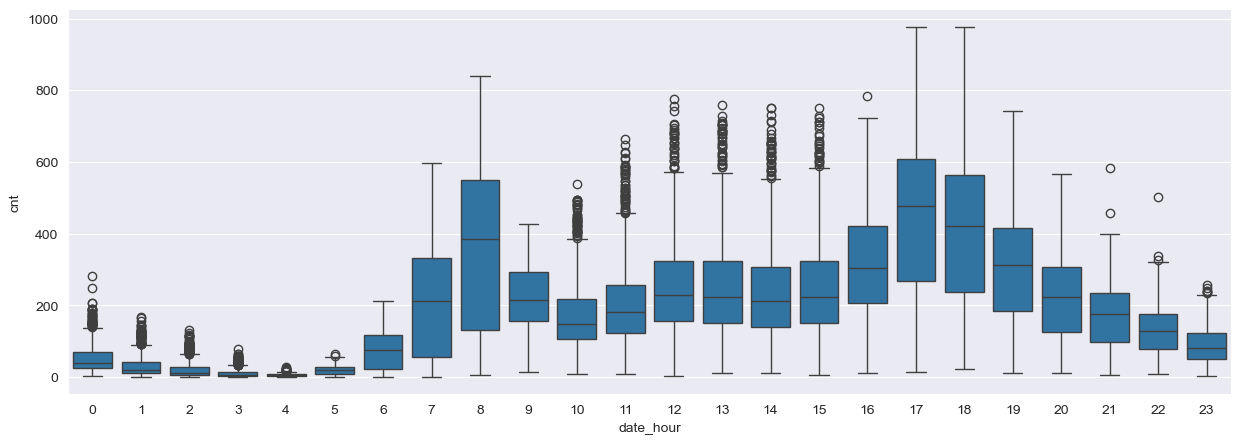

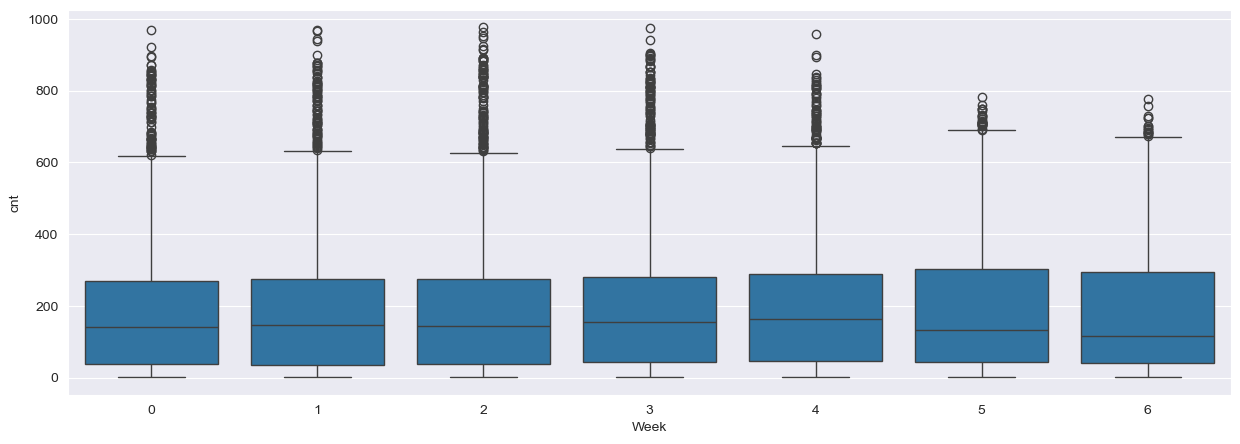

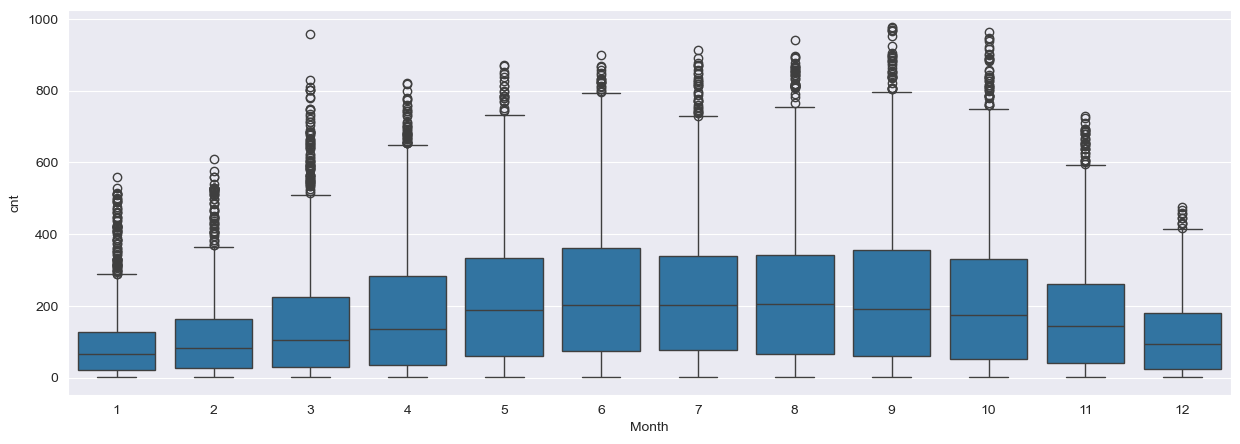

In [7]:
# Hourly patterns
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_decomp.index.hour, y=df_decomp['cnt'])
plt.show()
# Weekly patterns
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_decomp.index.dayofweek, y=df_decomp['cnt'])
plt.xlabel('Week')
plt.show()
# Monthly patterns
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_decomp.index.month, y=df_decomp['cnt'])
plt.xlabel('Month')
plt.show()

### 2.4. Lagging:

In deze stap heb ik gekozen voor 5 verschillende lag features. Lag -1 is meegenomen omdat deze een hoge partial autocorrelation heeft door hoe dichtbij het ligt. Lag -24 is gekozen vanwege de sterke daily seasonality in de data. Voor weekpatronen is er lag -168, met een merkbare partial autocorrelation, maar die is minder belangrijk vergeleken met de daily lag. Ook is lag -720 meegenomen voor monthly patronen. Ten slotte is er een yearly lag van -8760, omdat de visualisaties een duidelijk jaarlijks patroon laten zien, al kan dit niet echt als seasonality gelabeld worden door de beperkte hoeveelheid data.

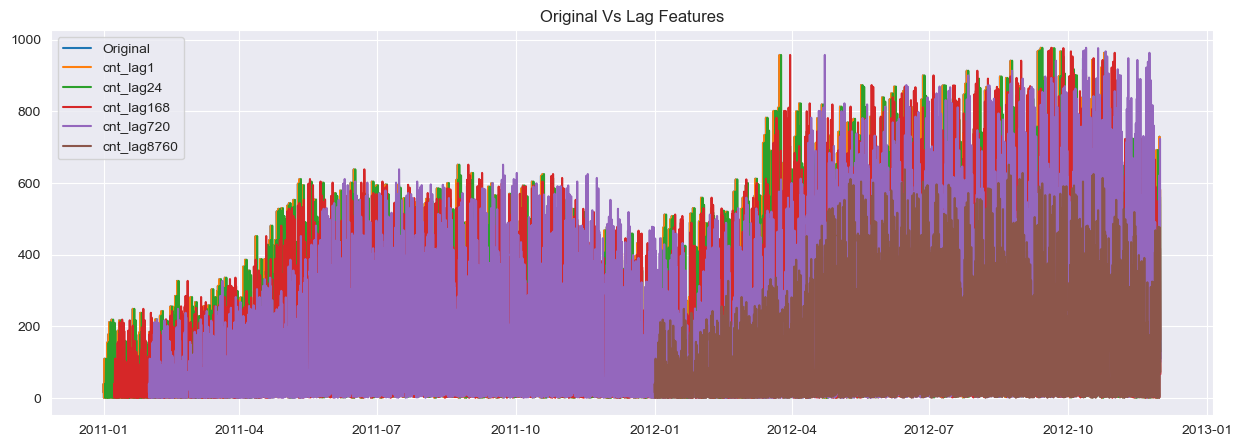

,holiday,weathersit,temp,atemp,hum,windspeed,cnt,trend,seasonal,resid,cnt_lag1,cnt_lag24,cnt_lag168,cnt_lag720,cnt_lag8760
date_hour,,,,,,,,,,,,,,,
2012-11-30 19:00:00,0.0,1.0,0.32,0.3485,0.66,0.0000,377.0,204.887129,125.718526,46.394345,509.0,344.0,154.0,410.0,228.0
2012-11-30 20:00:00,0.0,1.0,0.32,0.3485,0.66,0.0000,245.0,204.972222,39.655528,0.372250,377.0,252.0,142.0,268.0,190.0
2012-11-30 21:00:00,0.0,1.0,0.30,0.3182,0.75,0.0896,183.0,205.137177,-14.920873,-7.216304,245.0,208.0,98.0,192.0,162.0
2012-11-30 22:00:00,0.0,1.0,0.30,0.3333,0.75,0.0000,163.0,205.394422,-56.349224,13.954802,183.0,151.0,79.0,165.0,104.0
2012-11-30 23:00:00,0.0,2.0,0.30,0.3182,0.75,0.0896,110.0,205.716567,-100.890305,5.173739,163.0,130.0,67.0,101.0,73.0


In [8]:
from functions.feature_engineering_timeseries import lag_featuring
lags_to_use = [1, 24, 24*7, 24*30, 24*365]  # 1h, 1 day, 1 week, 1 month, 1 year
seasonal_lags = lag_featuring(df_decomp, target_col='cnt', lags=lags_to_use)
df_lagged = df_decomp.merge(seasonal_lags, left_index=True, right_index=True)
display(df_lagged.tail())

### 2.5. Frequency Domain (Domain Analise):

Ik heb een low-pass filter gebruikt om de langzamere en betrouwbare frequentieveranderingen te isoleren. Frequency 1 is ongeveer 0.04, wat overeenkomt met een periode van 24 uur. Frequency 2 is ongeveer 0.08, wat neerkomt op een periode van 12 uur. Deze kolommen laten zien wat "time of the day" het is voor het model op een encoded manier.

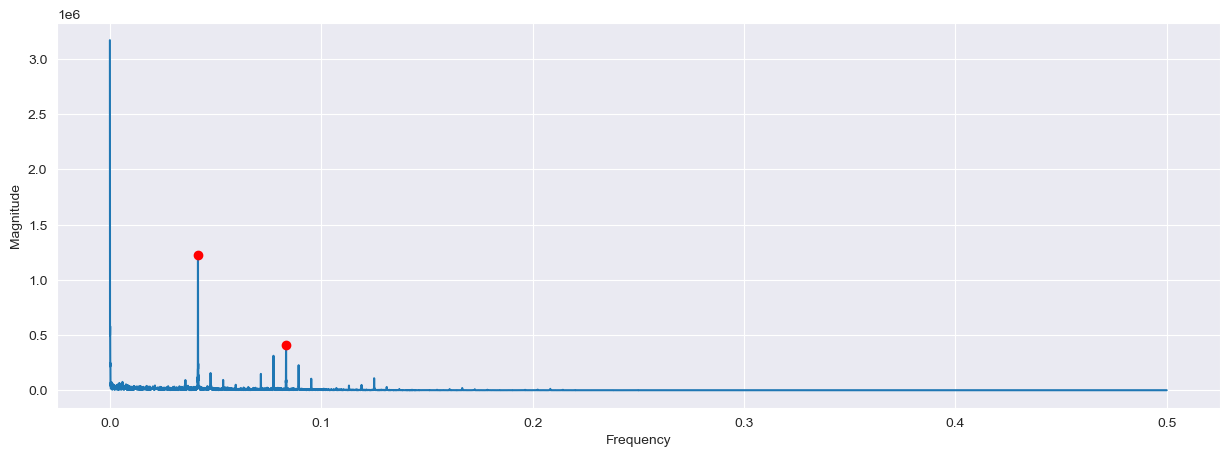

[24. 12.]
                     holiday  weathersit  temp   atemp   hum  windspeed  \
date_hour                                                                 
2011-01-01 00:00:00      0.0         1.0  0.24  0.2879  0.81     0.0000   
2011-01-01 01:00:00      0.0         1.0  0.22  0.2727  0.80     0.0000   
2011-01-01 02:00:00      0.0         1.0  0.22  0.2727  0.80     0.0000   
2011-01-01 03:00:00      0.0         1.0  0.24  0.2879  0.75     0.0000   
2011-01-01 04:00:00      0.0         1.0  0.24  0.2879  0.75     0.0000   
...                      ...         ...   ...     ...   ...        ...   
2012-11-30 19:00:00      0.0         1.0  0.32  0.3485  0.66     0.0000   
2012-11-30 20:00:00      0.0         1.0  0.32  0.3485  0.66     0.0000   
2012-11-30 21:00:00      0.0         1.0  0.30  0.3182  0.75     0.0896   
2012-11-30 22:00:00      0.0         1.0  0.30  0.3333  0.75     0.0000   
2012-11-30 23:00:00      0.0         2.0  0.30  0.3182  0.75     0.0896   

              

In [9]:
from functions.feature_engineering_timeseries import frequency_featuring
freqs, magnitude, peaks, periods = frequency_featuring(df_lagged, 'cnt', sample_interval=1, filter_cutoff=0.2)
print(periods)
df_fft = df_lagged.copy()
n = len(df_fft)
# 24h period
period_24h = 24
df_fft['sin_24h'] = np.sin(2 * np.pi * np.arange(n) / period_24h)
# 12h period
period_12h = 12
df_fft['sin_12h'] = np.sin(2 * np.pi * np.arange(n) / period_12h)
print(df_fft)

### 2.6. Time Series Feature Validation:

Lagged features presteren het beste, maar ook de andere features doen het duidelijk beter dan de originele. Dat maakt deze stap in de time series feature engineering een enorm success.

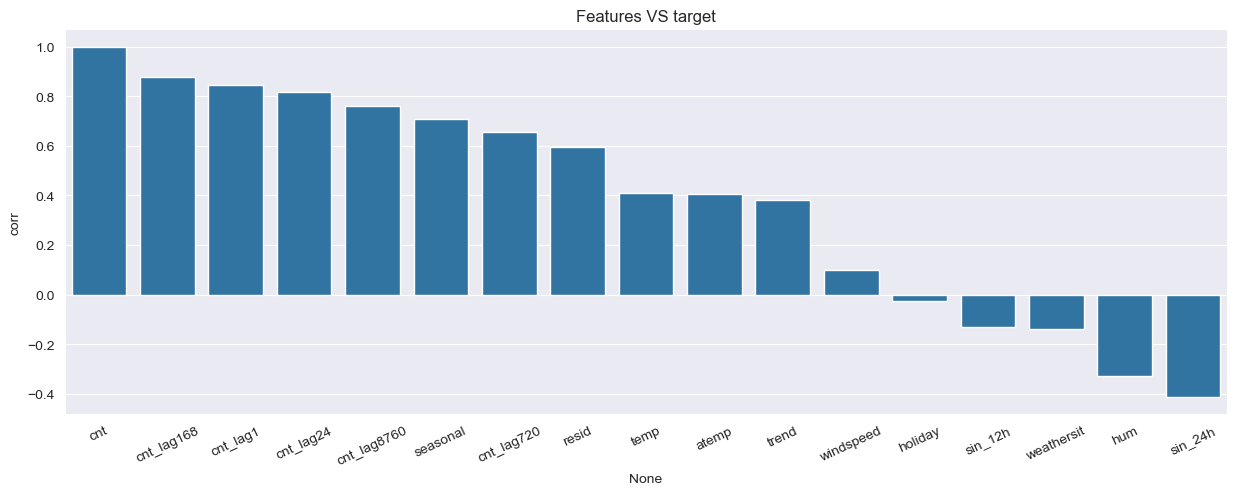

holiday         163
weathersit      163
temp            163
atemp           163
hum             163
windspeed       163
cnt             163
trend             0
seasonal          0
resid             0
cnt_lag1          1
cnt_lag24        24
cnt_lag168      168
cnt_lag720      720
cnt_lag8760    8760
sin_24h           0
sin_12h           0
dtype: int64
holiday        0
weathersit     0
temp           0
atemp          0
hum            0
windspeed      0
cnt            0
trend          0
seasonal       0
resid          0
cnt_lag1       0
cnt_lag24      0
cnt_lag168     0
cnt_lag720     0
cnt_lag8760    0
sin_24h        0
sin_12h        0
dtype: int64


In [10]:
features = ['holiday','weathersit','temp','atemp','hum','windspeed',
            'cnt_lag1','cnt_lag24','cnt_lag168','cnt_lag720','cnt_lag8760',
            'sin_24h','sin_12h','trend','seasonal','resid']
corrs = df_fft[features + ['cnt']].corr()['cnt'].sort_values(ascending=False)
plt.figure(figsize=(15, 5))
sns.barplot(x=corrs.index, y=corrs.values)
plt.xticks(rotation=25)
plt.ylabel("corr")
plt.title("Features VS target")
plt.show()
print(df_fft.isnull().sum())

# Filling categorical features with mode
for col in ['holiday','weathersit']:
    df_fft[col] = df_fft[col].fillna(df_fft[col].mode()[0])
# Filling numeric original features with mean
for col in ['temp','atemp','hum','windspeed','cnt']:
    df_fft[col] = df_fft[col].fillna(df_fft[col].mean())
# Filling lag features with overall mean of cnt
for col in ['cnt_lag1','cnt_lag24','cnt_lag168','cnt_lag720','cnt_lag8760']:
    df_fft[col] = df_fft[col].fillna(df_fft['cnt'].mean())

print(df_fft.isnull().sum())

# 3. Predictive Modeling:

### 3.1. Linear Regression Model:

### 3.2. Boosting Model:

### 3.3. Random model 1

### 3.4. Random model 2

### 3.5. Random model 3

### 3.6. SARIMA(X) Model:

### 3.7. Some other time series specific model:

### 3.8. Hybrid Model:

# 4. Conclusie:

text

# 5. Referentielijst

[ChatGPT, 2025. Prompt 1: Fix categorical Relationship Measures](https://chatgpt.com/share/6907d713-6cbc-800a-979b-7f884d973ed3)

[ChatGPT, 2025. Prompt 1: Efficiently compute hourly autocorrelation and seasonality for tons of samples](https://chatgpt.com/share/6918b8b3-7614-800a-94cf-17ee24f7a208)

[ChatGPT, 2025. Prompt 2: Fix error and get low-pass criteria filtering](https://chatgpt.com/share/691cc27c-cca4-800a-b6c7-146b772c4a7b)

[ChatGPT, 2025. Prompt 1: Fix lag_featuring function's iteration](https://chatgpt.com/share/691cd79e-0eb4-800a-8687-93b8b4e236aa)

